# Set environment

In [1]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys

### import flowImg
py_path = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image"
sys.path.insert(0, py_path)
from flowImg import *

### global const
SEED    = 123
DAT_DIR = "/data/clintko/flow_EQAPOL_normal/pipe01"

/local_data/env-py3/lib/python3.6/site-packages/h5py/__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


# Load data

In [2]:
!ls /data/clintko/flow_EQAPOL_normal/pipe01

wrap01_data.P	    wrap03_subs_1e4_N100.P  wrap04_tsne_1e4_N10.P
wrap02_scaled_k0.P  wrap03_subs_1e4_N10.P


In [3]:
fname = "wrap04_tsne_1e4_N10.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")

wrap_tsne = pickle.load(file)
file.close()

In [4]:
print(wrap_tsne)

Label: Counter({0: 110, 1: 110, 2: 110})
    0: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109]
    1: [110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127
 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145
 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163
 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181
 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199
 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217
 218 219]
    2: [220 221 222 223 224 225 226 227 228 229 2

**visualization**

In [5]:
idx1 = wrap_tsne.which_label(0)[:3]
idx2 = wrap_tsne.which_label(1)[:3]
idx3 = wrap_tsne.which_label(2)[:3]
indices = np.concatenate([idx1, idx2, idx3])
indices

array([  0,   1,   2, 110, 111, 112, 220, 221, 222])

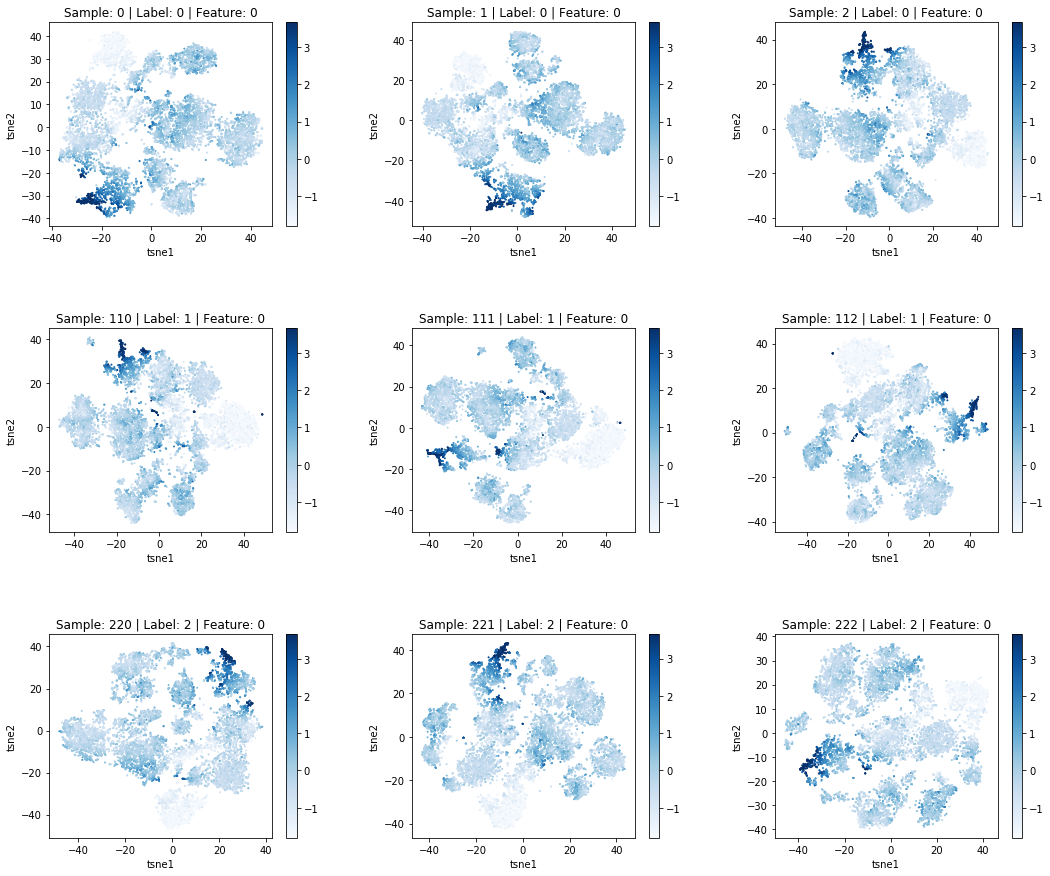

In [6]:
fig, axes = plt.subplots(ncols=3, nrows=3, figsize=(6*3, 5*3))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
axes = axes.ravel()

for idx in range(9):
    ax = axes[idx]
    cax = wrap_tsne.plot_coord(ax, k=indices[idx], p = 0, s = 1, cmap = "Blues")
    ax.set_xlabel("tsne1"); ax.set_ylabel("tsne2")
    fig.colorbar(cax, ax=ax)
pass

# Kernel Smoothing

In [7]:
%%time
density = Transform_Density(sig2 = 1)
wrap_img_var01 = density.transform(wrap_tsne, verbose = True)

Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample: 85
Sample: 86
Sample: 87
Sample: 88
Sample: 89
Sample: 90
Sample: 9

In [8]:
%%time
density = Transform_Density(sig2 = 2)
wrap_img_var02 = density.transform(wrap_tsne, verbose = True)

Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample: 85
Sample: 86
Sample: 87
Sample: 88
Sample: 89
Sample: 90
Sample: 9

In [9]:
%%time
density = Transform_Density(sig2 = 5)
wrap_img_var05 = density.transform(wrap_tsne, verbose = True)

Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample: 85
Sample: 86
Sample: 87
Sample: 88
Sample: 89
Sample: 90
Sample: 9

In [14]:
%%time
density = Transform_Density(sig2 = 10)
wrap_img_var10 = density.transform(wrap_tsne, verbose = True)

Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample: 85
Sample: 86
Sample: 87
Sample: 88
Sample: 89
Sample: 90
Sample: 9

# Store the results

In [10]:
### set up a pickle file
fname = "wrap05_img_1e4_var01.P"
fpath = os.path.join(DAT_DIR, fname)
file = open(fpath, 'wb')

### store the dictionary
pickle.dump(wrap_img_var01, file)
file.close()

In [11]:
### set up a pickle file
fname = "wrap05_img_1e4_var02.P"
fpath = os.path.join(DAT_DIR, fname)
file = open(fpath, 'wb')

### store the dictionary
pickle.dump(wrap_img_var02, file)
file.close()

In [12]:
### set up a pickle file
fname = "wrap05_img_1e4_var05.P"
fpath = os.path.join(DAT_DIR, fname)
file = open(fpath, 'wb')

### store the dictionary
pickle.dump(wrap_img_var05, file)
file.close()

In [15]:
### set up a pickle file
fname = "wrap05_img_1e4_var10.P"
fpath = os.path.join(DAT_DIR, fname)
file = open(fpath, 'wb')

### store the dictionary
pickle.dump(wrap_img_var10, file)
file.close()

In [16]:
!ls /data/clintko/flow_EQAPOL_normal/pipe01

wrap01_data.P		wrap03_subs_1e4_N10.P	wrap05_img_1e4_var02.P
wrap02_scaled_k0.P	wrap04_tsne_1e4_N10.P	wrap05_img_1e4_var05.P
wrap03_subs_1e4_N100.P	wrap05_img_1e4_var01.P	wrap05_img_1e4_var10.P
